# Distracted Driver Detection
**Branch:** dev-black 'Essawy'

## temp download (req.txt later)

In [2]:
!pip install mediapipe==0.10.14
%pip install ultralytics

import numpy as np
import matplotlib.pyplot as plt
import torch.nn
import matplotlib
import seaborn as sns
import pandas as pd
import os
import cv2
import mediapipe as mp
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, classification_report
from sklearn.preprocessing import LabelEncoder, StandardScaler

from tqdm import tqdm # if you are going to use tqdm, make sure to import it this way, otherwise it will not render properly in Github Repos
import torch
import torch.nn as nn
import torchvision
from torch.utils.data import TensorDataset, DataLoader, Subset, random_split, Dataset
from torchvision import datasets, transforms
import numpy as np
from PIL import Image
import random


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 53.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.2/295.2 kB 23.2 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.5
    Uninstalling protobuf-5.29.5:
      Successfully uninstalled protobuf-5.29.5
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.25.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
a2a-sdk 0.3.25 requires protobuf>=5.29.5, but you have protobuf 4.25.9 which is incompatible.
grain 0.2.15 requires protobuf>=5.28.3, but you have protobuf 4.25.9 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.9 which is incompatible.
opentelemetry-proto 1.3

2026-03-26 00:19:50.449027: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774484390.653381      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774484390.707437      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774484391.148018      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774484391.148064      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774484391.148068      55 computation_placer.cc:177] computation placer alr

# Load Data

In [3]:
base_path = '/kaggle/input/competitions/state-farm-distracted-driver-detection'
path_DriverList = os.path.join(base_path, 'driver_imgs_list.csv')
imagesPath = os.path.join(base_path, 'imgs')
trainPath = os.path.join(base_path, 'imgs/train')
testPath = os.path.join(base_path, 'imgs/test')

## Class map for readability

In [4]:

class_map = { 
    'c0': 'Normal Driving',
    'c1': 'Texting - Right',
    'c2': 'Talking on Phone - Right',
    'c3': 'Texting - Left',
    'c4': 'Talking on Phone - Left',
    'c5': 'Operating Radio',
    'c6': 'Drinking',
    'c7': 'Reaching Behind',
    'c8': 'Hair and Makeup',
    'c9': 'Talking to Passenger'
}

## Check the distribution of classes and view a sample image from each class.

Number of images per class:
class_desc
Normal Driving              2489
Texting - Left              2346
Talking on Phone - Left     2326
Drinking                    2325
Talking on Phone - Right    2317
Operating Radio             2312
Texting - Right             2267
Talking to Passenger        2129
Reaching Behind             2002
Hair and Makeup             1911
Name: count, dtype: int64
------------------------------
Total Images: 22424
Total Test Images: 79726


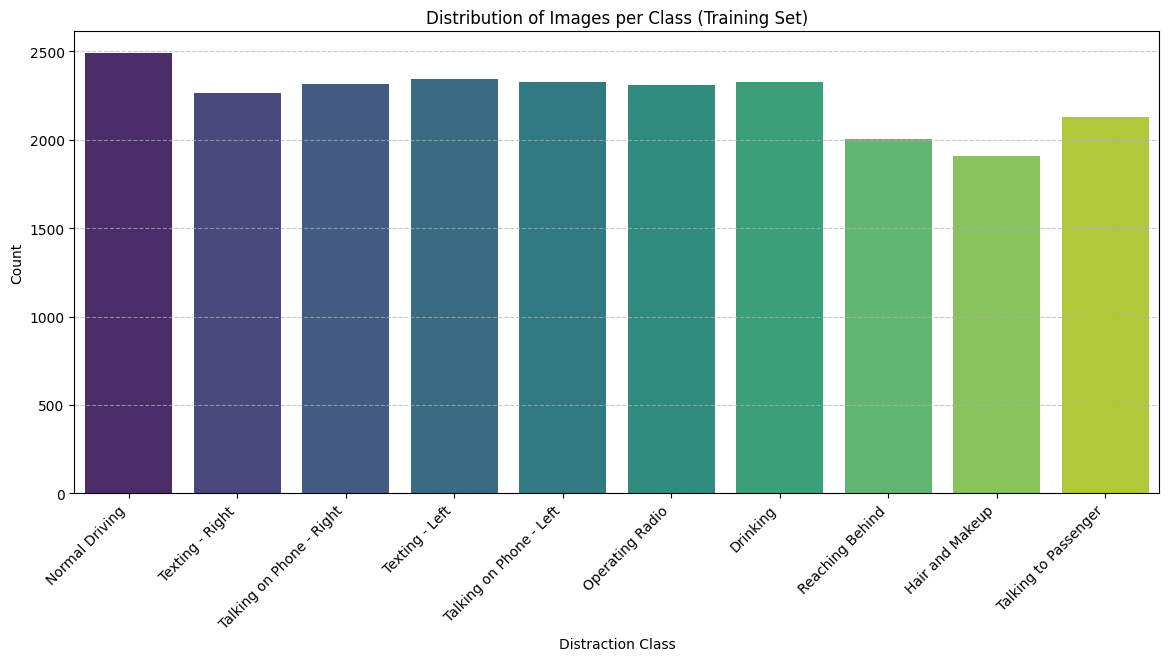

In [5]:
# 1. Load the CSV
df_drivers = pd.read_csv(path_DriverList)

# Map the classname to the actual text using our class_map so the plot looks good
df_drivers['class_desc'] = df_drivers['classname'].map(class_map)

# Print the exact number of images per class
print("Number of images per class:")
print(df_drivers['class_desc'].value_counts())
print("-" * 30)
print(f"Total Images: {len(df_drivers)}")

# Count images in the test directory
test_images_count = len([f for f in os.listdir(testPath) if f.endswith('.jpg')])

print("=" * 30)
print(f"Total Test Images: {test_images_count}")
print("=" * 30)

# Plotting with the fixed warning
plt.figure(figsize=(14, 6))
sns.countplot(
    data=df_drivers, 
    x='class_desc', 
    hue='class_desc', # Added this to fix the warning
    legend=False,     # Added this to fix the warning
    palette='viridis', 
    order=[class_map[f'c{i}'] for i in range(10)]
)
plt.title('Distribution of Images per Class (Training Set)')
plt.xlabel('Distraction Class')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

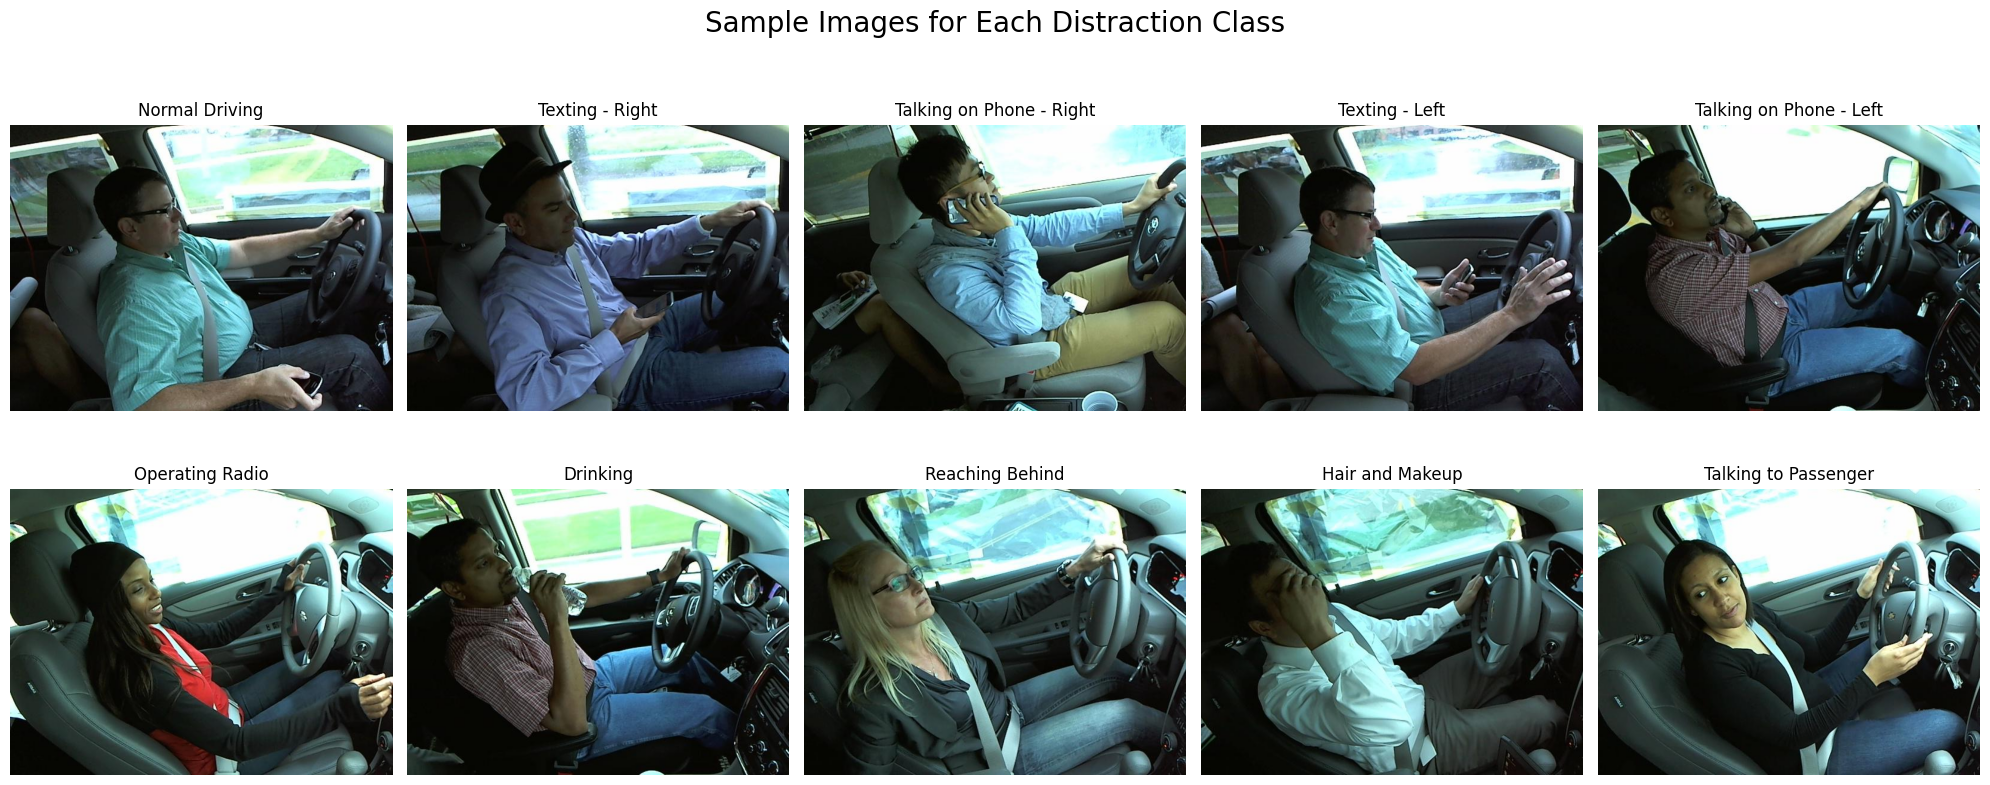

In [6]:
classes = sorted(os.listdir(trainPath)) # List c0, c1...c9
plt.figure(figsize=(20, 8))

for i, class_name in enumerate(classes):
    # Get the path to the first image in each class folder
    class_folder = os.path.join(trainPath, class_name)
    img_name = os.listdir(class_folder)[0]
    img_path = os.path.join(class_folder, img_name)

    # Load and convert to RGB
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Plotting
    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.title(f"{class_map[class_name]}")
    plt.axis('off')

plt.tight_layout()
plt.suptitle('Sample Images for Each Distraction Class', fontsize=20, y=1.05)
plt.show()

# Pose Estimation Experiment (MediaPipe vs YOLO)
Testing if extracting the driver's skeleton can be a useful feature for our model.
Comparing RGB vs Grayscale performance.

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1774484416.928426     146 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1774484416.966236     146 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


MediaPipe vs YOLOv8 (RGB and Grayscale comparison)


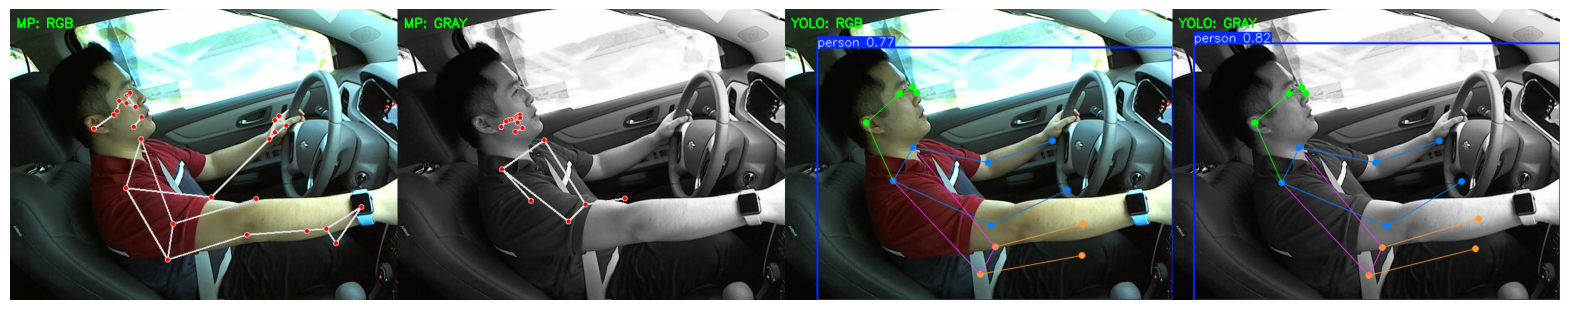

In [7]:
from ultralytics import YOLO

# 1. Setup Models
mp_pose = mp.solutions.pose
mp_drawing = mp.solutions.drawing_utils
pose = mp_pose.Pose(static_image_mode=True, min_detection_confidence=0.3)
yolo_model = YOLO('yolov8n-pose.pt')

# 2. Load and Prepare Images
img_path = f"{base_path}/imgs/train/c5/img_56882.jpg"
img_bgr = cv2.imread(img_path)

# Create the Grayscale 3-Channel (Fake RGB)
img_gray_only = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
img_gray_3ch = cv2.cvtColor(img_gray_only, cv2.COLOR_GRAY2BGR)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# 3. Run Detections
results_mp_rgb = pose.process(img_rgb)
results_mp_gray = pose.process(img_gray_3ch)

# YOLO on RGB vs YOLO on Gray
results_yolo_rgb = yolo_model(img_bgr, conf=0.1, verbose=False) # BGR is fine for YOLO
results_yolo_gray = yolo_model(img_gray_3ch, conf=0.1, verbose=False)

# 4. Drawing Helper
def draw_mp(img, results, title):
    annotated = img.copy()
    if results.pose_landmarks:
        mp_drawing.draw_landmarks(annotated, results.pose_landmarks, mp_pose.POSE_CONNECTIONS)
        color = (0, 255, 0)
    else:
        color = (0, 0, 255)
    cv2.putText(annotated, title, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)
    return annotated

# 5. Generate Panels
panel1 = draw_mp(img_bgr, results_mp_rgb, "MP: RGB")
panel2 = draw_mp(img_gray_3ch, results_mp_gray, "MP: GRAY")

# YOLO plotting (returns BGR)
panel3 = results_yolo_rgb[0].plot()
cv2.putText(panel3, "YOLO: RGB", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

panel4 = results_yolo_gray[0].plot()
cv2.putText(panel4, "YOLO: GRAY", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

# Ensure all panels are the same size for concatenation
h, w = panel1.shape[:2]
panels = [cv2.resize(p, (w, h)) for p in [panel1, panel2, panel3, panel4]]

# 6. Show Result (Fixed cv2_imshow issue for Kaggle)
print("MediaPipe vs YOLOv8 (RGB and Grayscale comparison)")
final_panel = cv2.hconcat(panels)
plt.figure(figsize=(20, 10))
plt.imshow(cv2.cvtColor(final_panel, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

In [8]:
# Custom Dataset for Test Folder
class StateFarmTestDataset(Dataset):
    def __init__(self, root_dir, transform=None, frac=1.0):
        self.root_dir = root_dir
        self.transform = transform
        
        all_files = sorted([f for f in os.listdir(root_dir) if f.endswith('.jpg')])
        
        # Take a subset of the massive test data
        if frac < 1.0:
            sample_size = int(len(all_files) * frac)
            random.seed(42)
            self.image_files = random.sample(all_files, sample_size)
        else:
            self.image_files = all_files

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.root_dir, img_name)
        
        # Open image and convert DIRECTLY to Grayscale ('L' mode)
        image = Image.open(img_path).convert('L')
        
        if self.transform:
            image = self.transform(image)
            
        return image, img_name

In [9]:
# Transformations (Notice Grayscale is the only format now)
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomAffine(degrees=0, shear=15),
    transforms.RandomRotation(10),
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

# Load Datasets (Convert train images to Grayscale as well using a lambda function)
grayscale_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transform
])

full_train_dataset = datasets.ImageFolder(root=trainPath, transform=grayscale_transform)
test_dataset = StateFarmTestDataset(root_dir=testPath, transform=transform, frac=0.1)

# Stratified Split
targets = np.array(full_train_dataset.targets)
train_sub_idx, val_sub_idx = train_test_split(
    np.arange(len(targets)),
    test_size=0.1,
    stratify=targets,
    shuffle=True,
    random_state=42
)

train_subset = Subset(full_train_dataset, train_sub_idx)
val_subset = Subset(full_train_dataset, val_sub_idx)

# DataLoaders
train_loader = DataLoader(train_subset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print("-" * 30)
print(f"Images ready for Training: {len(train_subset)}")
print(f"Images ready for Validation: {len(val_subset)}")
print(f"Images ready for Testing (10% subset): {len(test_dataset)}")
print("-" * 30)

------------------------------
Images ready for Training: 20181
Images ready for Validation: 2243
Images ready for Testing (10% subset): 7972
------------------------------


# Following the golden rule; Building the Baseline CNN Model
#### We are building a simple Convolutional Neural Network to test our pipeline.

In [10]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(BaselineCNN, self).__init__()
        
        # Convolutional Layers to extract features
        self.features = nn.Sequential(
            # Block 1: Input (1, 256, 256) -> Output (16, 128, 128)
            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # Block 2: Input (16, 128, 128) -> Output (32, 64, 64)
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            # Block 3: Input (32, 64, 64) -> Output (64, 32, 32)
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            # Block 4: Input (64, 32, 32) -> Output (128, 16, 16)
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            # Block 5: Input (128, 16, 16) -> Output (128, 8, 8)
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        
        # Fully Connected Layers for classification
        # Flattened size: 128 channels * 8 width * 8 height = 8192
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.5), # Helps prevent overfitting
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

print("Baseline CNN Architecture defined!")

Baseline CNN Architecture defined!


## Setting up the Training Environment
- Initialize our model
- Choose our loss function (CrossEntropy for classification)
- Set up the optimizer.
- Move the model to the GPU if it is available.

In [26]:
# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Initialize Model
model = BaselineCNN(num_classes=10).to(device)

# Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("Model, Loss Function, and Optimizer are ready!")

Using device: cuda
Model, Loss Function, and Optimizer are ready!


## A Quick Test Loop (1 Epoch)
Before writing the full training script with validation metrics and saving the best model, let's just run 1 epoch to ensure everything is working without errors.

In [27]:
# Run a quick test for just 1 epoch
num_epochs = 1

print("Starting quick test training...")

for epoch in range(num_epochs):
    model.train() # Set model to training mode
    running_loss = 0.0
    
    # Use tqdm to show a progress bar
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
    
    for images, labels in progress_bar:
        # Move data to GPU if available
        images, labels = images.to(device), labels.to(device)
        
        # 1. Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # 2. Backward pass and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Update loss
        running_loss += loss.item()
        
        # Update progress bar
        progress_bar.set_postfix(loss=loss.item())
        
    epoch_loss = running_loss / len(train_loader)
    print(f"\nEpoch [{epoch+1}/{num_epochs}] completed. Average Training Loss: {epoch_loss:.4f}")

Starting quick test training...


Epoch 1/1: 100%|██████████| 1262/1262 [04:40<00:00,  4.50it/s, loss=2.36]


Epoch [1/1] completed. Average Training Loss: 2.3014
